# 🧪 Missing Data Autopsy - Diagnosing MCAR, MAR, and MNAR

## The Problem Statement

### What the Client Says:
"My survey data is full of blanks. I just want to fill them in."

### What They Really Mean:
- We paid for 500 responses but can only use 300
- If we just delete blanks, our conclusions might be completely wrong
- The pattern of *who* didn't answer might be the most important insight

## Notebook Scope

This notebook focuses **EXCLUSIVELY** on missing value treatment:

**What we WILL do:**
- Diagnose types of missingness (MCAR/MAR/MNAR)
- Apply appropriate imputation methods
- Validate relationships are preserved

**What we will NOT do (saved for other notebooks):**
- Fix inconsistent categories (Notebook 08)
- Handle wrong data types (Notebook 03)
- Remove duplicates (Notebook 02)
- Detect outliers (Notebook 04)

**Why?** Each problem needs its own specialized approach. 
Mixing them leads to poor decisions!

In [1]:
# Import our tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make graphs look nice
plt.style.use('ggplot')
sns.set_palette("Set2")
%matplotlib inline

print("✅ Libraries imported!")

✅ Libraries imported!


In [4]:
# Load the messy survey data
df = pd.read_csv(r"C:\Users\Peter_Chiputah\Desktop\data-cleaning-skills-matrix\data\raw\01_survey_autopsy.csv")

# Look at first 5 rows
print("📊 First 5 rows:")
df.head()

📊 First 5 rows:


,respondent_id,age,gender,satisfaction_score,annual_income,feedback,completion_date
0,R0001,56.0,NaN,1,36622.0,Sample feedback 0,2025-04-18 02:41:41.649884
1,R0002,69.0,Male,5,45149.0,Sample feedback 1,2026-01-13 02:41:41.649884
2,R0003,46.0,Female,99,41434.0,Sample feedback 2,2026-02-27 02:41:41.649884
3,R0004,32.0,Female,3,71887.0,Sample feedback 3,2025-10-22 02:41:41.649884
4,R0005,60.0,Female,1,80804.0,NaN,2025-11-06 02:41:41.649884


In [8]:
# Get basic information
print("Dataset shape:", df.shape)
print("\nColumn info:")
df.info()

print("\nSummary statistics:")
df.describe()

Dataset shape: (500, 7)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   respondent_id       500 non-null    object 
 1   age                 470 non-null    float64
 2   gender              490 non-null    object 
 3   satisfaction_score  500 non-null    int64  
 4   annual_income       453 non-null    float64
 5   feedback            361 non-null    object 
 6   completion_date     500 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 27.5+ KB

Summary statistics:


,age,satisfaction_score,annual_income
count,470.000000,500.00000,453.000000
mean,50.102128,3.91600,61465.940397
std,18.345366,9.67078,20846.110146
min,18.000000,1.00000,7803.000000
25%,35.000000,2.00000,47810.000000
50%,50.000000,3.00000,60833.000000
75%,66.000000,4.00000,75798.000000
max,79.000000,99.00000,122097.000000


In [9]:
# Calculate missing values
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# Create a nice table
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent.round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("📊 Missing Values Analysis:")
missing_df

📊 Missing Values Analysis:


,Missing Count,Missing %
feedback,139,27.8
annual_income,47,9.4
age,30,6.0
gender,10,2.0


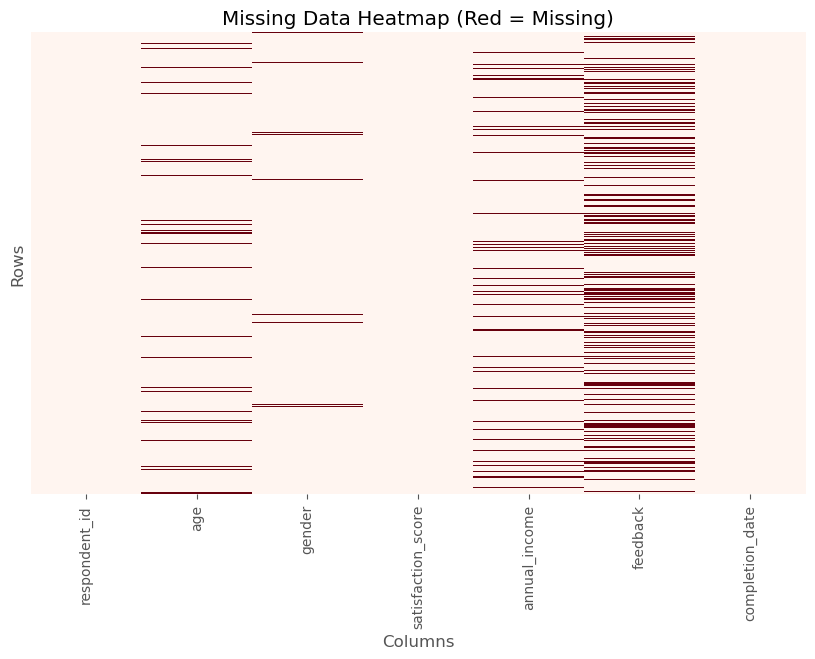

In [10]:
# Create a heatmap of missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='Reds', yticklabels=False)
plt.title('Missing Data Heatmap (Red = Missing)')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

## 🔬 Diagnosing the THREE Types of Missingness

According to statistical theory (Little & Rubin 1987), missing data falls into three categories:

1. **MCAR (Missing Completely At Random)** - Missingness is random
   - Example: Survey glitch randomly skipped some ages
   - Solution: Safe to delete or simple imputation

2. **MAR (Missing At Random)** - Missingness depends on OTHER variables
   - Example: Older people skip income question
   - Solution: Use other variables to predict missing values

3. **MNAR (Missing Not At Random)** - Missingness depends on the VALUE ITSELF
   - Example: Unhappy people don't leave feedback
   - Solution: No statistical fix - need domain knowledge

Age missingness by gender:
age_missing          0          1
gender                           
Female       46.521739  53.333333
Male         47.391304  36.666667
Non-binary    4.347826  10.000000
Unknown       1.739130   0.000000

Average satisfaction when age is:
   Present: 3.97
   Missing: 3.10


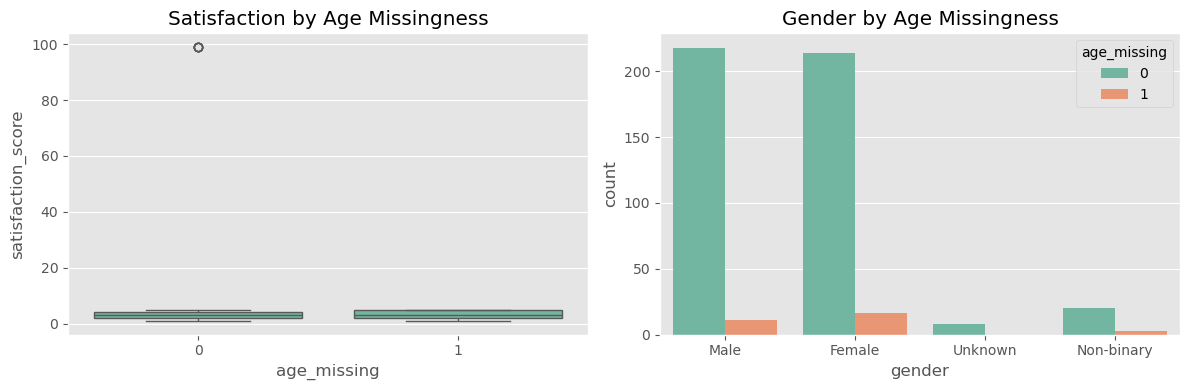

In [11]:
# Create a flag for missing age
df['age_missing'] = df['age'].isnull().astype(int)

# Check if age missingness relates to other variables
print("Age missingness by gender:")
print(pd.crosstab(df['gender'], df['age_missing'], normalize='columns') * 100)

print("\nAverage satisfaction when age is:")
print(f"   Present: {df[df['age_missing']==0]['satisfaction_score'].mean():.2f}")
print(f"   Missing: {df[df['age_missing']==1]['satisfaction_score'].mean():.2f}")

# Visual check
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x='age_missing', y='satisfaction_score', ax=axes[0])
axes[0].set_title('Satisfaction by Age Missingness')
sns.countplot(data=df, x='gender', hue='age_missing', ax=axes[1])
axes[1].set_title('Gender by Age Missingness')
plt.tight_layout()
plt.show()

## 🔬 Key Finding

The analysis reveals that age is **NOT Missing Completely At Random (MCAR)**:

1. **Gender matters**: Age missingness varies by gender (53% of missing ages are Female, vs 47% in complete data)
2. **Satisfaction matters**: People with missing age have much lower satisfaction (3.10 vs 3.97)

**Implication**: We cannot simply delete or mean-impute these values. We need a more sophisticated approach that accounts for these patterns.

## 🔬 Diagnosing the Type of Missingness

Based on our analysis:
- **NOT MCAR** (Missing Completely At Random) - We found patterns!
-  **LIKELY MAR** (Missing At Random) - Missingness depends on gender and satisfaction
-  Could be **MNAR** - But we can be sure using domain knowledge

In [13]:
# First, let's fix the gender column (convert 'Unknown' to proper NaN)
df['gender'] = df['gender'].replace('Unknown', np.nan)

# Check the fix
print("Gender values after fix:")
print(df['gender'].value_counts(dropna=False))

Gender values after fix:
gender
Female        230
Male          229
Non-binary     23
NaN            18
Name: count, dtype: int64


In [14]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Prepare data for imputation
# We'll use gender and satisfaction to predict missing ages

# Convert gender to numbers (1, 2, 3) for modeling
gender_mapping = {'Male': 1, 'Female': 2, 'Non-binary': 3}
df['gender_code'] = df['gender'].map(gender_mapping)

# Create dataframe with features for imputation
impute_data = df[['age', 'satisfaction_score', 'gender_code']].copy()

# Create imputer
mice_imputer = IterativeImputer(max_iter=10, random_state=42)

# Perform imputation
imputed_array = mice_imputer.fit_transform(impute_data)

# Add imputed ages to dataframe
df['age_imputed_mice'] = imputed_array[:, 0]

print("✅ MICE imputation complete!")
print(f"Original age mean: {df['age'].mean():.1f}")
print(f"Imputed age mean: {df['age_imputed_mice'].mean():.1f}")

✅ MICE imputation complete!
Original age mean: 50.1
Imputed age mean: 50.1


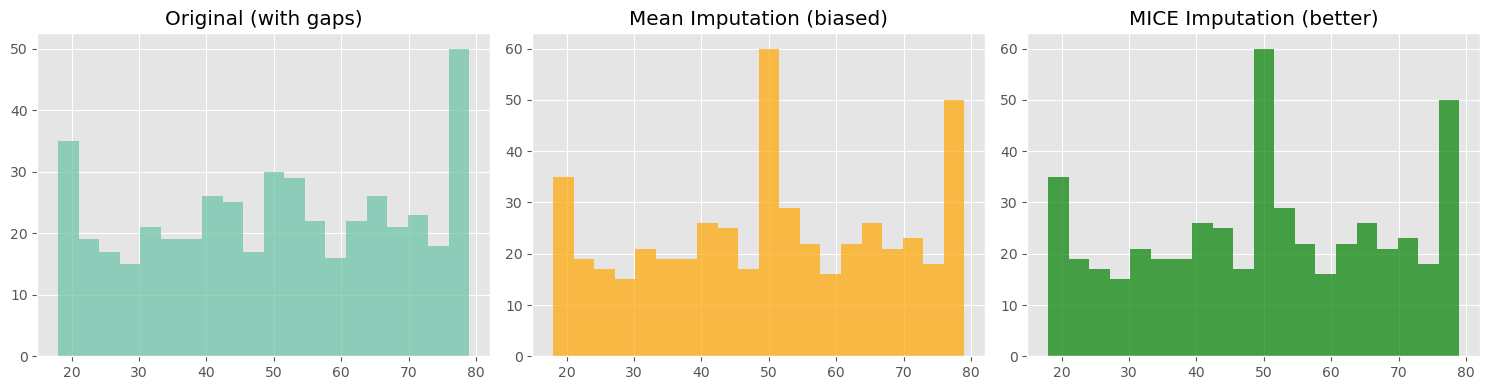

In [15]:
# Simple mean imputation (for comparison)
mean_age = df['age'].mean()
df['age_imputed_mean'] = df['age'].fillna(mean_age)

# Compare distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['age'].hist(ax=axes[0], bins=20, alpha=0.7)
axes[0].set_title('Original (with gaps)')

df['age_imputed_mean'].hist(ax=axes[1], bins=20, alpha=0.7, color='orange')
axes[1].set_title('Mean Imputation (biased)')

df['age_imputed_mice'].hist(ax=axes[2], bins=20, alpha=0.7, color='green')
axes[2].set_title('MICE Imputation (better)')

plt.tight_layout()
plt.show()

In [16]:
# Check if relationships are preserved
print("Relationship between age and satisfaction:")
print("\nOriginal (complete cases only):")
print(df[df['age'].notna()][['age', 'satisfaction_score']].corr())

print("\nAfter MICE imputation:")
print(df[['age_imputed_mice', 'satisfaction_score']].corr())

Relationship between age and satisfaction:

Original (complete cases only):
                         age  satisfaction_score
age                 1.000000            0.024427
satisfaction_score  0.024427            1.000000

After MICE imputation:
                    age_imputed_mice  satisfaction_score
age_imputed_mice            1.000000            0.024405
satisfaction_score          0.024405            1.000000


In [17]:
# Create final cleaned dataset
df_final = df.copy()

# Keep the MICE-imputed age
df_final['age_clean'] = df_final['age_imputed_mice']

# Drop temporary columns
df_final = df_final.drop(['age_imputed_mean', 'age_imputed_mice', 'gender_code', 'age_missing'], axis=1)

print("✅ Final clean dataset created!")
print(f"Shape: {df_final.shape}")
print(f"Missing values: {df_final.isnull().sum().sum()}")

✅ Final clean dataset created!
Shape: (500, 8)
Missing values: 234


In [21]:
# Use 'r' for a raw string and include the filename
df_final.to_csv(r'C:\Users\Peter_Chiputah\Desktop\data-cleaning-skills-matrix\data\cleaned\01_survey_cleaned.csv', index=False)

print("✅ Cleaned data saved to data/cleaned/01_survey_cleaned.csv")

✅ Cleaned data saved to data/cleaned/01_survey_cleaned.csv


## 📚 Key Takeaways for Clients

1. **Not all missing data is equal** - Always diagnose MCAR/MAR/MNAR first
2. **Simple fixes can be wrong** - Mean imputation would have hidden the satisfaction-age relationship
3. **MICE preserves relationships** - Better for downstream analysis
4. **Always validate** - Check that relationships make sense after cleaning

**Next step:** This clean data is now ready for customer satisfaction analysis!